In [3]:
import pandas as pd
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from spacy import displacy, tokenizer
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
from gensim.models import LsiModel, TfidfModel
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from pathlib import Path


In [4]:
parent_dir = Path.cwd().parent

In [8]:
data = pd.read_csv(parent_dir.joinpath("Supporting_Docs").joinpath("fake_news_data.csv"))

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 1.0, 'Count of aricle classification')

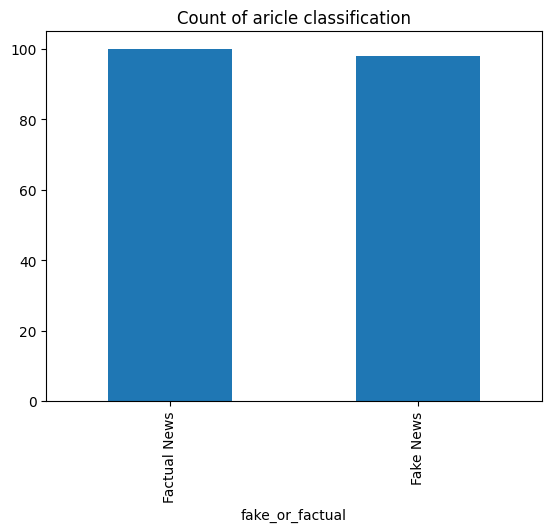

In [11]:
data['fake_or_factual'].value_counts().plot(kind='bar')
plt.title("Count of aricle classification")

POS Tagging

In [13]:
nlp = spacy.load('en_core_web_sm')

In [14]:
fake_news = data[data['fake_or_factual'] == 'Fake News']
factual_news = data[data['fake_or_factual'] == 'Factual News']

In [20]:
fake_spacy_docs = list(nlp.pipe(fake_news['text']))
factual_spacy_docs = list(nlp.pipe(factual_news['text']))

nlp.pipe() creates an easy way to inject the array and do the same fuction on each item of array which generates the output. List then capures it and storpes in a list format

In [24]:
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return[(item.text, item.ent_type_, item.pos_) for item in doc]

In [36]:
columns = ["token","ner_tag","pos_tag"]
faketag_df = pd.DataFrame(columns=columns)

In [41]:
for i, doc in enumerate(fake_spacy_docs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    faketag_df = pd.concat([faketag_df,tags])

In [43]:
factualtag_df = pd.DataFrame(columns=columns)

In [44]:
for i, doc in enumerate(factual_spacy_docs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    factualtag_df = pd.concat([factualtag_df,tags])

In [45]:
factualtag_df

,token,ner_tag,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT
...,...,...,...
85,citing,,VERB
86,three,CARDINAL,NUM
87,unnamed,,ADJ
88,officials,,NOUN


Next i am counting the same token and Parts of speech tag in the entire fake and factual data.

In [53]:
pos_count_fake = faketag_df.groupby(['token','pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)
pos_count_fake
#.size()

,token,pos_tag,count
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
...,...,...,...
3770,detectives,VERB,1
3769,detective,NOUN,1
3768,detained,VERB,1
3766,detail,NOUN,1


In [54]:
pos_count_factual = factualtag_df.groupby(['token','pos_tag']).size().reset_index(name='count').sort_values(by='count', ascending=False)
pos_count_factual

,token,pos_tag,count
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
...,...,...,...
2909,crossing,VERB,1
2911,crucial,ADJ,1
2913,cruise,NOUN,1
2914,crusade,NOUN,1


I observe that both have mostly the similar kind of frequently occuring combo and so i decided now to check if certain parts of speech is occuring more in fake data

In [61]:
pos_count_fake.groupby('pos_tag')['token'].size().sort_values(ascending=False)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64

In [62]:
pos_count_factual.groupby('pos_tag')['token'].size().sort_values(ascending=False)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
SPACE      11
CCONJ      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64

Again it was observed tha sanme NOUN VERB PROPN are the order. so I will deep dive into Noun specificity

In [63]:
pos_count_fake[pos_count_fake['pos_tag']=="NOUN"]

,token,pos_tag,count
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
...,...,...,...
3781,developments,NOUN,1
3778,devastation,NOUN,1
3772,determination,NOUN,1
3769,detective,NOUN,1


In [65]:
pos_count_factual[pos_count_factual['pos_tag']=="NOUN"]

,token,pos_tag,count
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
...,...,...,...
2905,cross,NOUN,1
2907,crosses,NOUN,1
2908,crossing,NOUN,1
2913,cruise,NOUN,1


NAMED ENTITIES

In [66]:
names_entities_fake = faketag_df[faketag_df['ner_tag'] != ""].groupby(['token','ner_tag']).size().reset_index(name='count').sort_values(by='count',ascending=False)
names_entities_fake

,token,ner_tag,count
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
...,...,...,...
886,Hempstead,GPE,1
885,Helbig,PERSON,1
884,Hedge,PERSON,1
883,Heather,PERSON,1


In [67]:
names_entities_factual = factualtag_df[factualtag_df['ner_tag'] != ""].groupby(['token','ner_tag']).size().reset_index(name='count').sort_values(by='count',ascending=False)
names_entities_factual

,token,ner_tag,count
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
...,...,...,...
804,German,NORP,1
803,Georgia,GPE,1
801,George,ORG,1
800,Geological,ORG,1


In [69]:
ner_pallete = {
    'ORG' : sns.color_palette('Set2').as_hex()[0],
    'PERSON' : sns.color_palette('Set2').as_hex()[1],
    'GPE' : sns.color_palette('Set2').as_hex()[2],
    'DATE' : sns.color_palette('Set2').as_hex()[3],
    'NORP' : sns.color_palette('Set2').as_hex()[4],
    'CARDINAL' : sns.color_palette('Set2').as_hex()[5],
    'PERCENT' : sns.color_palette('Set2').as_hex()[6],
}

[Text(0.5, 1.0, 'Most common Names Entity in Fake News')]

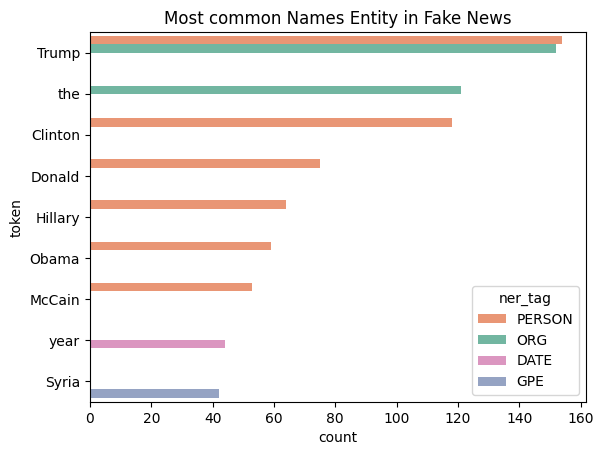

In [73]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_pallete,
    data = names_entities_fake[:10],
    orient = 'h',
    dodge = True
).set(title = "Most common Names Entity in Fake News")

[Text(0.5, 1.0, 'Most common Names Entity in Factual News')]

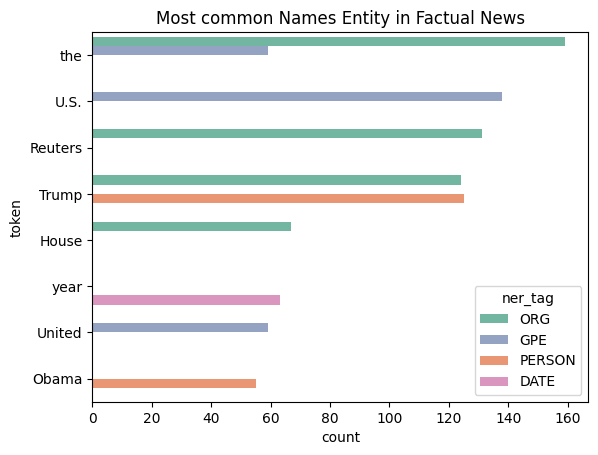

In [74]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_pallete,
    data = names_entities_factual[:10],
    orient = 'h',
    dodge = True
).set(title = "Most common Names Entity in Factual News")